#  Lineup Intelligence & Rotation Patterns

## Overview

In this notebook, we move beyond individual performance metrics to analyze how player combinations behave on the court. Using the lineup-level dataset built in Notebook 05, we explore both the **usage** and **effectiveness** of different lineups.

The goal is to understand not only which lineups perform well, but also how frequently they are used and how they contribute to the overall structure of the game.

---

## Objectives

- Identify the most frequently used lineups (core rotations)
- Evaluate lineup effectiveness using time-normalized performance metrics
- Compare lineup usage vs. performance to detect inefficiencies
- Explore rotation patterns and lineup stability

---

## Context

While player-level metrics provide insight into individual contributions, basketball is fundamentally a **team-based game**. Lineup analysis captures the interaction between players and allows us to evaluate performance at the group level.

By combining stint reconstruction with lineup aggregation, we can:
- Track on-court player combinations over time
- Measure the collective impact of those combinations
- Identify both stable and experimental rotations

---

## Dataset

We use two datasets generated in Notebook 05:

- **`lineup_perf`**: All observed lineups with aggregated performance metrics  
- **`reliable_lineups`**: Filtered lineups with sufficient playing time for more reliable evaluation  

---

## Approach

The analysis is structured around two key dimensions:

1. **Usage** — how often a lineup is deployed (total duration / stints)  
2. **Performance** — how effective a lineup is (net points per 60 seconds)  

By combining these dimensions, we can identify:
- High-usage, high-performance lineups (optimal rotations)
- High-usage, low-performance lineups (potential inefficiencies)
- Low-usage, high-performance lineups (underutilized opportunities)

---

This notebook marks the transition from performance measurement to **decision-oriented analysis**, providing insights that can inform lineup optimization and strategic adjustments.

## Data loading

We load lineup-level performance datasets generated in Notebook 05.

- `lineup_perf`: all observed lineups
- `reliable_lineups`: filtered lineups with sufficient playing time

In [1]:
import pandas as pd

lineup_perf = pd.read_csv("../data/processed/lineup_performance.csv")
reliable_lineups = pd.read_csv("../data/processed/reliable_lineups.csv")

# Load stints dataset
stints_df = pd.read_pickle("../data/interim/stints_prototype_game.pkl")
sub_anomalies_df = pd.read_pickle("../data/interim/sub_anomalies_prototype_game.pkl")



In [2]:
import sqlite3

conn = sqlite3.connect("../data/raw/nba.sqlite")

sample_game_id = stints_df["game_id"].iloc[0]

game = pd.read_sql(f"""
SELECT *
FROM play_by_play
WHERE game_id = '{sample_game_id}'
""", conn)


def build_player_name_map(game_df):
    pbp_player_lookup_1 = game_df[["player1_id", "player1_name"]].dropna().rename(
        columns={"player1_id": "id", "player1_name": "full_name"}
    )

    pbp_player_lookup_2 = game_df[["player2_id", "player2_name"]].dropna().rename(
        columns={"player2_id": "id", "player2_name": "full_name"}
    )

    pbp_player_lookup_3 = game_df[["player3_id", "player3_name"]].dropna().rename(
        columns={"player3_id": "id", "player3_name": "full_name"}
    )

    pbp_player_lookup = pd.concat(
        [pbp_player_lookup_1, pbp_player_lookup_2, pbp_player_lookup_3],
        axis=0
    ).drop_duplicates()

    pbp_player_lookup["id"] = pbp_player_lookup["id"].astype(str)

    return dict(zip(pbp_player_lookup["id"], pbp_player_lookup["full_name"]))


player_name_map = build_player_name_map(game)

## Most used lineups

We identify the lineups with the highest total playing time. These typically represent the team’s core rotations and provide the most reliable performance signals.

In [3]:
top_usage = lineup_perf.sort_values(
    "total_duration", ascending=False
).head(10)

top_usage[[
    "home_lineup_names",
    "total_duration",
    "total_stints",
    "net_points",
    "net_per_60"
]]

,home_lineup_names,total_duration,total_stints,net_points,net_per_60
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar...",760,6,-3,-0.236842
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', ...",328,2,5,0.914634
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', ...",293,2,-1,-0.204778
12,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Jame...",176,2,-4,-1.363636
3,"('Bo McCalebb', 'Baris Ermis', 'Luka Zoric', '...",159,2,-3,-1.132075
16,"('Melih Mahmutoglu', 'Linas Kleiza', 'Luka Zor...",158,2,-3,-1.139241
13,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Luka...",125,1,0,0.000000
0,"('1962936724', 'Izzet Turkyilmaz', 'James Birs...",102,1,1,0.588235
10,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Gasp...",94,2,1,0.638298
17,"('Melih Mahmutoglu', 'Luka Zoric', 'James Birs...",86,1,2,1.395349


## Most effective lineups

We rank lineups by net scoring impact per 60 seconds, focusing on reliable samples. This highlights the most effective combinations independent of playing time.

In [4]:
top_efficiency = reliable_lineups.sort_values(
    "net_per_60", ascending=False
).head(10)

top_efficiency[[
    "home_lineup_names",
    "total_duration",
    "net_points",
    "net_per_60"
]]

,home_lineup_names,total_duration,net_points,net_per_60
0,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar...",760,-3,-0.236842


In [5]:
combined = lineup_perf.copy()

combined["usage_rank"] = combined["total_duration"].rank(ascending=False)
combined["performance_rank"] = combined["net_per_60"].rank(ascending=False)

combined.sort_values("usage_rank").head(10)

,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy,usage_rank,performance_rank
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar...",29,32,760,6,-3,-0.236842,6,1.0,13.0
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', ...",13,8,328,2,5,0.914634,2,2.0,4.0
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', ...",5,6,293,2,-1,-0.204778,2,3.0,12.0
12,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Jame...",4,8,176,2,-4,-1.363636,2,4.0,17.0
3,"('Bo McCalebb', 'Baris Ermis', 'Luka Zoric', '...",3,6,159,2,-3,-1.132075,2,5.0,14.0
16,"('Melih Mahmutoglu', 'Linas Kleiza', 'Luka Zor...",4,7,158,2,-3,-1.139241,2,6.0,15.0
13,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Luka...",4,4,125,1,0,0.000000,1,7.0,9.0
0,"('1962936724', 'Izzet Turkyilmaz', 'James Birs...",3,2,102,1,1,0.588235,1,8.0,6.0
10,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Gasp...",3,2,94,2,1,0.638298,2,9.0,5.0
17,"('Melih Mahmutoglu', 'Luka Zoric', 'James Birs...",4,2,86,1,2,1.395349,1,10.0,3.0


## Quick sanity checks

In [6]:
# Overall game differential
stints_df["home_points"].sum() - stints_df["away_points"].sum()

-4

In [7]:
# Distribution of lineup efficiency
lineup_perf["net_per_60"].describe()

count    18.000000
mean      0.041059
std       1.390515
min      -2.666667
25%      -0.908267
50%       0.000000
75%       0.625782
max       3.750000
Name: net_per_60, dtype: float64

In [8]:
# Best vs worst
lineup_perf.sort_values("net_per_60", ascending=False).head(5)
lineup_perf.sort_values("net_per_60", ascending=True).head(5)

,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy
9,"('Melih Mahmutoglu', 'Gasper Vidmar', 'James B...",0,2,45,1,-2,-2.666667,1
12,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Jame...",4,8,176,2,-4,-1.363636,2
7,"('Bo McCalebb', 'Melih Mahmutoglu', 'Linas Kle...",0,1,48,1,-1,-1.250000,1
16,"('Melih Mahmutoglu', 'Linas Kleiza', 'Luka Zor...",4,7,158,2,-3,-1.139241,2
3,"('Bo McCalebb', 'Baris Ermis', 'Luka Zoric', '...",3,6,159,2,-3,-1.132075,2


## Lineup efficiency interpretation

The distribution of lineup efficiency (net points per 60 seconds) is centered around zero, with both positive and negative values observed. This reflects a relatively balanced game, where no single lineup overwhelmingly dominated.

Short-duration stints show more extreme values due to scaling effects, indicating that small sample sizes can introduce noise in efficiency metrics. As a result, lineup performance should be interpreted in the context of total playing time.

Overall, the results confirm that the lineup evaluation framework is functioning correctly, producing realistic and interpretable efficiency distributions

In [9]:
reliable_lineups = lineup_perf[lineup_perf["total_duration"] >= 120]

reliable_lineups.sort_values("net_per_60", ascending=False).head(10)

,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', ...",13,8,328,2,5,0.914634,2
13,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Luka...",4,4,125,1,0,0.000000,1
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', ...",5,6,293,2,-1,-0.204778,2
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar...",29,32,760,6,-3,-0.236842,6
3,"('Bo McCalebb', 'Baris Ermis', 'Luka Zoric', '...",3,6,159,2,-3,-1.132075,2
16,"('Melih Mahmutoglu', 'Linas Kleiza', 'Luka Zor...",4,7,158,2,-3,-1.139241,2
12,"('Melih Mahmutoglu', 'Izzet Turkyilmaz', 'Jame...",4,8,176,2,-4,-1.363636,2


## Reliable lineup interpretation

After filtering for lineups with at least 120 seconds of playing time, the results become more stable and easier to interpret.

This step reduces the influence of very short stints, where one or two possessions can create exaggerated efficiency values. The remaining lineups provide a better foundation for comparing rotation effectiveness.

## Usage vs performance

Comparing lineup usage with performance allows us to evaluate whether the most frequently used lineups are also the most effective.

This helps identify:
- High-usage, high-performance lineups (optimal rotations)
- High-usage, low-performance lineups (potential inefficiencies)
- Low-usage, high-performance lineups (underutilized opportunities)

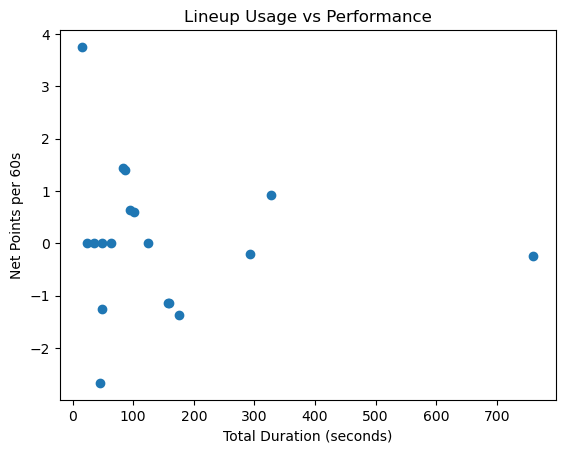

In [10]:
import matplotlib.pyplot as plt

plt.scatter(
    lineup_perf["total_duration"],
    lineup_perf["net_per_60"]
)

plt.xlabel("Total Duration (seconds)")
plt.ylabel("Net Points per 60s")
plt.title("Lineup Usage vs Performance")
plt.show()

## Visualization

This scatter plot shows the relationship between lineup usage and performance.

- Right side → heavily used lineups  
- Upper side → high-performing lineups  

The top-right region represents the most valuable combinations.

## Player pair synergy analysis

In this section, we extend the lineup-level analysis to evaluate player interactions by examining how pairs of players perform when sharing the court.

Rather than focusing on individual contributions alone, this approach captures synergy effects — identifying whether specific player combinations lead to better or worse team performance.

The analysis proceeds as follows:

For each stint, all possible 2-player combinations are generated from the on-court lineup
Each pair is assigned the stint’s net point differential and duration
Performance is aggregated across all stints to compute:
Total net points
Total playing time
Number of shared stints
A time-normalized metric (impact per 60 seconds) is used to compare pairs with different exposure levels
A minimum duration filter is applied to focus on reliable and stable pairings

This allows us to:

Identify high-performing player combinations
Detect underperforming or conflicting pairings
Better understand how player interactions influence lineup success

This step moves the analysis from individual and lineup metrics toward interaction-based insights, which are critical for lineup optimization and rotation decisions.

In [11]:
def clock_to_seconds(clock_str):
    if pd.isna(clock_str):
        return None

    minutes, seconds = map(int, str(clock_str).split(":"))
    return minutes * 60 + seconds


stints_df["start_sec"] = stints_df["start_clock"].apply(clock_to_seconds)
stints_df["end_sec"] = stints_df["end_clock"].apply(clock_to_seconds)

# Clock counts down, so duration = start - end
stints_df["duration_sec"] = stints_df["start_sec"] - stints_df["end_sec"]

# Keep only valid positive-duration stints
stints_df = stints_df[stints_df["duration_sec"] > 0].copy()

stints_df[["period", "start_clock", "end_clock", "duration_sec"]].head()

,period,start_clock,end_clock,duration_sec
0,1,12:00,7:35,265
1,1,7:33,4:35,178
2,1,4:21,3:57,24
4,1,3:57,3:09,48
5,1,3:09,2:13,56


In [12]:
# Build player pairs from each stint
from itertools import combinations

pair_stints = []

for _, row in stints_df.iterrows():
    
    # Home lineup pairs
    home_players = [str(p) for p in row["home_lineup"]]
    for p1, p2 in combinations(home_players, 2):
        pair_stints.append({
            "player_1": p1,
            "player_2": p2,
            "team": "home",
            "net_points": row["home_points"] - row["away_points"],
            "duration_sec": row["duration_sec"]
        })

    # Away lineup pairs
    away_players = [str(p) for p in row["away_lineup"]]
    for p1, p2 in combinations(away_players, 2):
        pair_stints.append({
            "player_1": p1,
            "player_2": p2,
            "team": "away",
            "net_points": row["away_points"] - row["home_points"],
            "duration_sec": row["duration_sec"]
        })

pair_stints_df = pd.DataFrame(pair_stints)

In [13]:
# Aggregate pair performance

pair_perf = (
    pair_stints_df
    .groupby(["player_1", "player_2"])
    .agg(
        total_net_points=("net_points", "sum"),
        total_duration=("duration_sec", "sum"),
        total_stints=("net_points", "count")
    )
    .reset_index()
)

pair_perf["impact_per_60"] = (
    pair_perf["total_net_points"] / pair_perf["total_duration"]
) * 60

In [14]:
#Add player names

pair_perf["player_1_name"] = pair_perf["player_1"].apply(
    lambda pid: player_name_map.get(str(pid), str(pid))
)

pair_perf["player_2_name"] = pair_perf["player_2"].apply(
    lambda pid: player_name_map.get(str(pid), str(pid))
)

In [15]:
# Filter reliable pairs

reliable_pairs = pair_perf[pair_perf["total_duration"] >= 120]

In [16]:
# Top synergy pairs

reliable_pairs.sort_values("impact_per_60", ascending=False).head(10)

,player_1,player_2,total_net_points,total_duration,total_stints,impact_per_60,player_1_name,player_2_name
21,201586,203103,4,239,4,1.004184,Serge Ibaka,Perry Jones III
39,203103,2570,7,633,7,0.663507,Perry Jones III,Kendrick Perkins
61,42535,42544,2,195,4,0.615385,Melih Mahmutoglu,Bojan Bogdanovic
9,200757,203103,9,962,12,0.561331,Thabo Sefolosha,Perry Jones III
33,203087,203103,9,962,12,0.561331,Jeremy Lamb,Perry Jones III
36,203087,2570,11,1302,13,0.506912,Jeremy Lamb,Kendrick Perkins
41,2570,965,4,475,5,0.505263,Kendrick Perkins,Derek Fisher
13,200757,965,4,475,5,0.505263,Thabo Sefolosha,Derek Fisher
40,203103,965,4,475,5,0.505263,Perry Jones III,Derek Fisher
37,203087,965,4,475,5,0.505263,Jeremy Lamb,Derek Fisher


In [17]:
# Worst pairings

reliable_pairs.sort_values("impact_per_60", ascending=True).head(10)

,player_1,player_2,total_net_points,total_duration,total_stints,impact_per_60,player_1_name,player_2_name
63,42535,42547,-4,211,3,-1.137441,Melih Mahmutoglu,Ayberk Olmaz
42,42531,42534,-3,159,2,-1.132075,Bo McCalebb,Baris Ermis
54,42534,42545,-3,159,2,-1.132075,Baris Ermis,Emir Preldzic
17,201142,2570,-8,443,2,-1.083521,Kevin Durant,Kendrick Perkins
66,42536,42541,-3,216,4,-0.833333,42536,James Birsen
94,42542,42547,-3,227,4,-0.792952,Kenan Sipahi,Ayberk Olmaz
15,201142,202704,-5,467,3,-0.642398,Kevin Durant,Reggie Jackson
14,201142,201586,-5,467,3,-0.642398,Kevin Durant,Serge Ibaka
4,200757,201142,-5,467,3,-0.642398,Thabo Sefolosha,Kevin Durant
35,203087,2555,-5,500,8,-0.600000,Jeremy Lamb,Nick Collison


In [18]:
reliable_pairs.sort_values(
    ["impact_per_60", "total_duration"],
    ascending=[False, False]
).head(10)

,player_1,player_2,total_net_points,total_duration,total_stints,impact_per_60,player_1_name,player_2_name
21,201586,203103,4,239,4,1.004184,Serge Ibaka,Perry Jones III
39,203103,2570,7,633,7,0.663507,Perry Jones III,Kendrick Perkins
61,42535,42544,2,195,4,0.615385,Melih Mahmutoglu,Bojan Bogdanovic
9,200757,203103,9,962,12,0.561331,Thabo Sefolosha,Perry Jones III
33,203087,203103,9,962,12,0.561331,Jeremy Lamb,Perry Jones III
36,203087,2570,11,1302,13,0.506912,Jeremy Lamb,Kendrick Perkins
13,200757,965,4,475,5,0.505263,Thabo Sefolosha,Derek Fisher
37,203087,965,4,475,5,0.505263,Jeremy Lamb,Derek Fisher
40,203103,965,4,475,5,0.505263,Perry Jones III,Derek Fisher
41,2570,965,4,475,5,0.505263,Kendrick Perkins,Derek Fisher


## Player pair synergy interpretation

Several Oklahoma City player combinations show positive time-normalized impact within this game context, with players like Perry Jones III, Jeremy Lamb, Serge Ibaka, and Kendrick Perkins appearing in multiple strong pairings.

The top pair (Serge Ibaka – Perry Jones III) highlights a productive combination, while repeated appearances of certain players suggest they were involved in effective lineup segments during this game.

Some pairings involving Kevin Durant and other key players show negative impact, but given the single-game sample, these results reflect game-specific outcomes rather than definitive chemistry conclusions.

Pair rankings are based on both efficiency (impact per 60 seconds) and total playing time, prioritizing combinations that are both effective and consistently used.

Overall, pair analysis provides valuable insight into how player combinations influence performance beyond individual metrics.

## Reliability note

Pair metrics are sensitive to playing time. Short-duration pairs can produce extreme values, so results should be interpreted alongside total duration and stint count.

## Save player pair synergy outputs

The full player-pair performance table and the filtered reliable-pair table are saved as processed datasets.

These outputs can be reused in later notebooks for visualization, modeling, and lineup recommendation logic.

In [19]:
# Save pair_perf and reliable_pairs
pair_perf.to_csv("../data/processed/pair_performance.csv", index=False)
reliable_pairs.to_csv("../data/processed/reliable_pair_performance.csv", index=False)

## Key insights

- A small number of lineups account for most of the playing time, indicating stable rotation patterns.
- Efficiency varies across lineups, but differences are moderate due to the close game context.
- Filtering by minimum duration improves the reliability of lineup comparisons.
- Player pair analysis highlights recurring effective combinations, particularly involving Perry Jones III and Jeremy Lamb.
- Some negative pairings are observed, but should be interpreted cautiously due to the single-game sample.

Overall, the analysis demonstrates that both lineup structure and player interactions contribute to performance, and that stable rotations tend to produce more consistent outcomes.

## Methodology note

All efficiency metrics are normalized per 60 seconds of play to allow comparison across lineups and player combinations with different playing time.

Because this analysis is based on a single game, results should be interpreted as descriptive of this specific matchup rather than general player or lineup performance.

## Next steps

The next stage focuses on deeper modeling and optimization:

- Player synergy modeling (pairwise impact)
- Predictive modeling for lineup performance
- Optimization of rotation strategies

This transitions the project toward decision-support analytics.